<a href="https://colab.research.google.com/github/Nirmalkumarganesan95/PySPark/blob/main/PySpark_SQL_Functions.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
!pip install pyspark

#PySpark Aggregate Functions

PySpark Aggregate Functions
PySpark SQL Aggregate functions are grouped as “agg_funcs” in Pyspark. Below is a list of functions defined under this group.

1.	approx_count_distinct
2.	avg
3.	collect_list
4.	collect_set
5.	countDistinct
6.	count
7.	grouping
8.	first
9.	last
10.	kurtosis
11.	max
12.	min
13.	mean
14.	skewness
15.	stddev
16.	stddev_samp
17.	stddev_pop
18.	sum
19.	sumDistinct
20.	variance, var_samp, var_pop


In [3]:
from pyspark.sql import SparkSession

spark = SparkSession.builder.appName('PySpark Aggregation').getOrCreate()

simpleData = [("James", "Sales", 3000),
    ("Michael", "Sales", 4600),
    ("Robert", "Sales", 4100),
    ("Maria", "Finance", 3000),
    ("James", "Sales", 3000),
    ("Scott", "Finance", 3300),
    ("Jen", "Finance", 3900),
    ("Jeff", "Marketing", 3000),
    ("Kumar", "Marketing", 2000),
    ("Saif", "Sales", 4100)
  ]
schema = ["employee_name", "department", "salary"]
df = spark.createDataFrame(data=simpleData, schema = schema)
df.printSchema()
df.show(truncate=False)

root
 |-- employee_name: string (nullable = true)
 |-- department: string (nullable = true)
 |-- salary: long (nullable = true)

+-------------+----------+------+
|employee_name|department|salary|
+-------------+----------+------+
|James        |Sales     |3000  |
|Michael      |Sales     |4600  |
|Robert       |Sales     |4100  |
|Maria        |Finance   |3000  |
|James        |Sales     |3000  |
|Scott        |Finance   |3300  |
|Jen          |Finance   |3900  |
|Jeff         |Marketing |3000  |
|Kumar        |Marketing |2000  |
|Saif         |Sales     |4100  |
+-------------+----------+------+



In [5]:
from pyspark.sql.functions import approx_count_distinct

#approx_count_distinct Aggregate Function
#In PySpark approx_count_distinct() function returns the count of distinct items in a group.
print("approx_count_distinct: " + str(df.select(approx_count_distinct("salary")).collect()[0][0]))

approx_count_distinct: 6


In [11]:
from pyspark.sql.functions import avg
#avg (average) Aggregate Function
print(f"Average: {str(df.select(avg('salary')).collect())}")
print(f"Average: {str(df.select(avg('salary')).collect()[0])}")
print(f"Average: {str(df.select(avg('salary')).collect()[0][0])}")

Average: [Row(avg(salary)=3400.0)]
Average: Row(avg(salary)=3400.0)
Average: 3400.0


In [18]:
from pyspark.sql.functions import collect_list
#collect List
df.select(collect_list('salary')).show(truncate=False)

+------------------------------------------------------------+
|collect_list(salary)                                        |
+------------------------------------------------------------+
|[3000, 4600, 4100, 3000, 3000, 3300, 3900, 3000, 2000, 4100]|
+------------------------------------------------------------+



In [19]:
from pyspark.sql.functions import collect_set
# Collect set -- Remove Duplicates
df.select(collect_set('salary')).show(truncate=False)

+------------------------------------+
|collect_set(salary)                 |
+------------------------------------+
|[2000, 3300, 4100, 3000, 4600, 3900]|
+------------------------------------+



In [22]:
#countDistinct Aggregate Function
#countDistinct() function returns the number of distinct elements in a columns
from pyspark.sql.functions import count_distinct
df2 = df.select(count_distinct("department", "salary"))
df2.show()
print("Distinct Count of Department & Salary: "+str(df2.collect()[0][0]))

+----------------------------------+
|count(DISTINCT department, salary)|
+----------------------------------+
|                                 8|
+----------------------------------+

Distinct Count of Department & Salary: 8


In [24]:
#count() function returns number of elements in a column.
from pyspark.sql.functions import *
print('count: '+ str(df.select(count("salary")).collect()[0][0]))

count: 10


In [28]:
#first function
#first() function returns the first element in a column when ignoreNulls is set to true, it returns the first non-null element.
df.select(first("salary")).show(truncate=False)

+-------------+
|first(salary)|
+-------------+
|3000         |
+-------------+



In [29]:
df.select(last('salary')).show()

+------------+
|last(salary)|
+------------+
|        4100|
+------------+



In [30]:
#kurtosis function
#kurtosis() function returns the kurtosis of the values in a group.
df.select(kurtosis('salary')).show()

+-------------------+
|   kurtosis(salary)|
+-------------------+
|-0.6467803030303032|
+-------------------+



In [31]:
#max function
df.select(max("salary")).show()

+-----------+
|max(salary)|
+-----------+
|       4600|
+-----------+



In [32]:
#min function
df.select(min("salary")).show()

+-----------+
|min(salary)|
+-----------+
|       2000|
+-----------+



In [33]:
#mean
df.select(mean("salary")).show(truncate=False)

+-----------+
|avg(salary)|
+-----------+
|3400.0     |
+-----------+



In [34]:
#skewness() function returns the skewness of the values in a group.
df.select(skewness("salary")).show(truncate=False)

+--------------------+
|skewness(salary)    |
+--------------------+
|-0.12041791181069571|
+--------------------+



stddev(), stddev_samp() and stddev_pop()
stddev() alias for stddev_samp.

stddev_samp() function returns the sample standard deviation of values in a column.

stddev_pop() function returns the population standard deviation of the values in a column.

In [35]:
df.select(stddev("salary"), stddev_samp("salary"), stddev_pop("salary")).show(truncate=False)

+-----------------+-------------------+------------------+
|stddev(salary)   |stddev_samp(salary)|stddev_pop(salary)|
+-----------------+-------------------+------------------+
|765.9416862050705|765.9416862050705  |726.636084983398  |
+-----------------+-------------------+------------------+



In [36]:
#sum
df.select(sum("salary")).show(truncate=False)

+-----------+
|sum(salary)|
+-----------+
|34000      |
+-----------+



In [37]:
#sumDistinct() function returns the sum of all distinct values in a column.
df.select(sum_distinct('salary')).show()

+--------------------+
|sum(DISTINCT salary)|
+--------------------+
|               20900|
+--------------------+



variance() alias for var_samp

var_samp() function returns the unbiased variance of the values in a column.

var_pop() function returns the population variance of the values in a column.

In [38]:
df.select(variance("salary"),var_samp("salary"),var_pop("salary")).show(truncate=False)

+-----------------+-----------------+---------------+
|variance(salary) |var_samp(salary) |var_pop(salary)|
+-----------------+-----------------+---------------+
|586666.6666666666|586666.6666666666|528000.0       |
+-----------------+-----------------+---------------+



#PySpark Window Functions

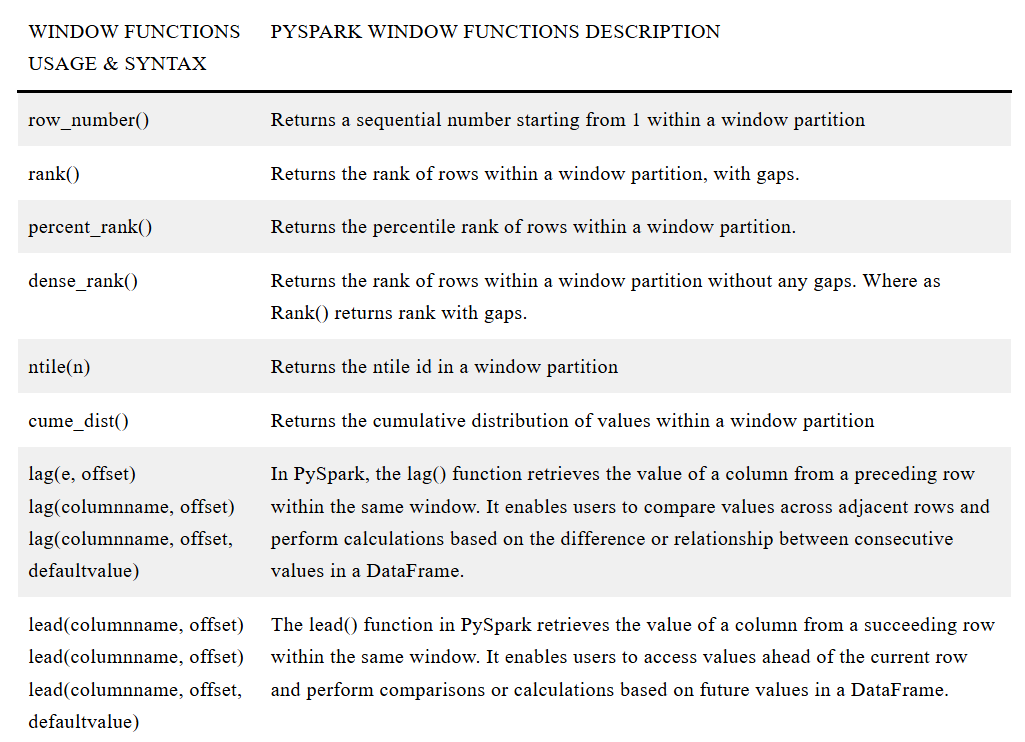

In [39]:
# Create SparkSession
spark = SparkSession.builder.appName('SparkByExamples.com').getOrCreate()

simpleData = (("James", "Sales", 3000), \
    ("Michael", "Sales", 4600),  \
    ("Robert", "Sales", 4100),   \
    ("Maria", "Finance", 3000),  \
    ("James", "Sales", 3000),    \
    ("Scott", "Finance", 3300),  \
    ("Jen", "Finance", 3900),    \
    ("Jeff", "Marketing", 3000), \
    ("Kumar", "Marketing", 2000),\
    ("Saif", "Sales", 4100) \
  )

columns= ["employee_name", "department", "salary"]
df = spark.createDataFrame(data = simpleData, schema = columns)
df.printSchema()
df.show(truncate=False)

root
 |-- employee_name: string (nullable = true)
 |-- department: string (nullable = true)
 |-- salary: long (nullable = true)

+-------------+----------+------+
|employee_name|department|salary|
+-------------+----------+------+
|James        |Sales     |3000  |
|Michael      |Sales     |4600  |
|Robert       |Sales     |4100  |
|Maria        |Finance   |3000  |
|James        |Sales     |3000  |
|Scott        |Finance   |3300  |
|Jen          |Finance   |3900  |
|Jeff         |Marketing |3000  |
|Kumar        |Marketing |2000  |
|Saif         |Sales     |4100  |
+-------------+----------+------+



In [41]:
from pyspark.sql.window import Window
from pyspark.sql.functions import row_number
windowSpec = Window.partitionBy('department').orderBy('salary')

df.withColumn("Row Number", row_number().over(windowSpec)).show()

+-------------+----------+------+----------+
|employee_name|department|salary|Row Number|
+-------------+----------+------+----------+
|        Maria|   Finance|  3000|         1|
|        Scott|   Finance|  3300|         2|
|          Jen|   Finance|  3900|         3|
|        Kumar| Marketing|  2000|         1|
|         Jeff| Marketing|  3000|         2|
|        James|     Sales|  3000|         1|
|        James|     Sales|  3000|         2|
|       Robert|     Sales|  4100|         3|
|         Saif|     Sales|  4100|         4|
|      Michael|     Sales|  4600|         5|
+-------------+----------+------+----------+



In [43]:
#2.2 rank Window Function
#rank() window function provides a rank to the result within a window partition. This function leaves gaps in rank when there are ties.
from pyspark.sql.window import *
df.withColumn("Rank", rank().over(windowSpec)).show()

+-------------+----------+------+----+
|employee_name|department|salary|Rank|
+-------------+----------+------+----+
|        Maria|   Finance|  3000|   1|
|        Scott|   Finance|  3300|   2|
|          Jen|   Finance|  3900|   3|
|        Kumar| Marketing|  2000|   1|
|         Jeff| Marketing|  3000|   2|
|        James|     Sales|  3000|   1|
|        James|     Sales|  3000|   1|
|       Robert|     Sales|  4100|   3|
|         Saif|     Sales|  4100|   3|
|      Michael|     Sales|  4600|   5|
+-------------+----------+------+----+



In [44]:
#2.3 dense_rank Window Function
#dense_rank() window function is used to get the result with rank of rows within a window partition without any gaps. This is similar to rank() function difference being rank function leaves gaps in rank when there are ties.
df.withColumn('Dense Rank', dense_rank().over(windowSpec)).show()

+-------------+----------+------+----------+
|employee_name|department|salary|Dense Rank|
+-------------+----------+------+----------+
|        Maria|   Finance|  3000|         1|
|        Scott|   Finance|  3300|         2|
|          Jen|   Finance|  3900|         3|
|        Kumar| Marketing|  2000|         1|
|         Jeff| Marketing|  3000|         2|
|        James|     Sales|  3000|         1|
|        James|     Sales|  3000|         1|
|       Robert|     Sales|  4100|         2|
|         Saif|     Sales|  4100|         2|
|      Michael|     Sales|  4600|         3|
+-------------+----------+------+----------+



In [45]:
#2.4 percent_rank Window Function
df.withColumn("Percent Rank", percent_rank().over(windowSpec)).show()

+-------------+----------+------+------------+
|employee_name|department|salary|Percent Rank|
+-------------+----------+------+------------+
|        Maria|   Finance|  3000|         0.0|
|        Scott|   Finance|  3300|         0.5|
|          Jen|   Finance|  3900|         1.0|
|        Kumar| Marketing|  2000|         0.0|
|         Jeff| Marketing|  3000|         1.0|
|        James|     Sales|  3000|         0.0|
|        James|     Sales|  3000|         0.0|
|       Robert|     Sales|  4100|         0.5|
|         Saif|     Sales|  4100|         0.5|
|      Michael|     Sales|  4600|         1.0|
+-------------+----------+------+------------+



In [46]:
#2.5 ntile Window Function
#ntile() window function returns the relative rank of result rows within a window partition. In the below example we have used 2 as an argument to ntile hence it returns ranking between 2 values (1 and 2)
df.withColumn("ntile",ntile(2).over(windowSpec)).show()

+-------------+----------+------+-----+
|employee_name|department|salary|ntile|
+-------------+----------+------+-----+
|        Maria|   Finance|  3000|    1|
|        Scott|   Finance|  3300|    1|
|          Jen|   Finance|  3900|    2|
|        Kumar| Marketing|  2000|    1|
|         Jeff| Marketing|  3000|    2|
|        James|     Sales|  3000|    1|
|        James|     Sales|  3000|    1|
|       Robert|     Sales|  4100|    1|
|         Saif|     Sales|  4100|    2|
|      Michael|     Sales|  4600|    2|
+-------------+----------+------+-----+



3. PySpark Window Analytic Functions

3.1 cume_dist Window Function

cume_dist(): This function computes the cumulative distribution of a value within a window partition. It calculates the relative rank of a value within the partition. The result ranges from 0 to 1, where a value of 0 indicates the lowest value in the partition, and 1 indicates the highest. It’s useful for understanding the distribution of values compared to others within the same partition.

In [47]:
df.withColumn("cume_dist",cume_dist().over(windowSpec)).show()

+-------------+----------+------+------------------+
|employee_name|department|salary|         cume_dist|
+-------------+----------+------+------------------+
|        Maria|   Finance|  3000|0.3333333333333333|
|        Scott|   Finance|  3300|0.6666666666666666|
|          Jen|   Finance|  3900|               1.0|
|        Kumar| Marketing|  2000|               0.5|
|         Jeff| Marketing|  3000|               1.0|
|        James|     Sales|  3000|               0.4|
|        James|     Sales|  3000|               0.4|
|       Robert|     Sales|  4100|               0.8|
|         Saif|     Sales|  4100|               0.8|
|      Michael|     Sales|  4600|               1.0|
+-------------+----------+------+------------------+



In [48]:
#3.2 lag Window Function
#This is the same as the LAG function in SQL. The lag() function allows you to access a previous row’s value within the partition based on a specified offset. It retrieves the column value from the previous row, which can be helpful for comparative analysis or calculating differences between consecutive rows.

# lag() Example
from pyspark.sql.functions import lag
df.withColumn("lag",lag("salary",2).over(windowSpec)).show()

+-------------+----------+------+----+
|employee_name|department|salary| lag|
+-------------+----------+------+----+
|        Maria|   Finance|  3000|NULL|
|        Scott|   Finance|  3300|NULL|
|          Jen|   Finance|  3900|3000|
|        Kumar| Marketing|  2000|NULL|
|         Jeff| Marketing|  3000|NULL|
|        James|     Sales|  3000|NULL|
|        James|     Sales|  3000|NULL|
|       Robert|     Sales|  4100|3000|
|         Saif|     Sales|  4100|3000|
|      Michael|     Sales|  4600|4100|
+-------------+----------+------+----+



3.3 lead Window Function

This is the same as the LEAD function in SQL. Similar to lag(), the lead() function retrieves the column value from the following row within the partition based on a specified offset. It helps in accessing subsequent row values for comparison or predictive analysis.

In [49]:
# lead() Example
from pyspark.sql.functions import lead
df.withColumn("lead",lead("salary",2).over(windowSpec)).show()

+-------------+----------+------+----+
|employee_name|department|salary|lead|
+-------------+----------+------+----+
|        Maria|   Finance|  3000|3900|
|        Scott|   Finance|  3300|NULL|
|          Jen|   Finance|  3900|NULL|
|        Kumar| Marketing|  2000|NULL|
|         Jeff| Marketing|  3000|NULL|
|        James|     Sales|  3000|4100|
|        James|     Sales|  3000|4100|
|       Robert|     Sales|  4100|4600|
|         Saif|     Sales|  4100|NULL|
|      Michael|     Sales|  4600|NULL|
+-------------+----------+------+----+



In [50]:
# Aggregate functions examples
windowSpecAgg  = Window.partitionBy("department")
from pyspark.sql.functions import col,avg,sum,min,max,row_number
df.withColumn("row",row_number().over(windowSpec)) \
  .withColumn("avg", avg(col("salary")).over(windowSpecAgg)) \
  .withColumn("sum", sum(col("salary")).over(windowSpecAgg)) \
  .withColumn("min", min(col("salary")).over(windowSpecAgg)) \
  .withColumn("max", max(col("salary")).over(windowSpecAgg)) \
  .where(col("row")==1).select("department","avg","sum","min","max") \
  .show()

+----------+------+-----+----+----+
|department|   avg|  sum| min| max|
+----------+------+-----+----+----+
|   Finance|3400.0|10200|3000|3900|
| Marketing|2500.0| 5000|2000|3000|
|     Sales|3760.0|18800|3000|4600|
+----------+------+-----+----+----+



#PySpark SQL Date and Timestamp

* DateType default format is yyyy-MM-dd
* TimestampType default format is yyyy-MM-dd HH:mm:ss.SSSS
* Returns null if the input is a string that can not be cast to Date or Timestamp

In [51]:
from pyspark.sql.functions import *

PySpark SQL Date Functions

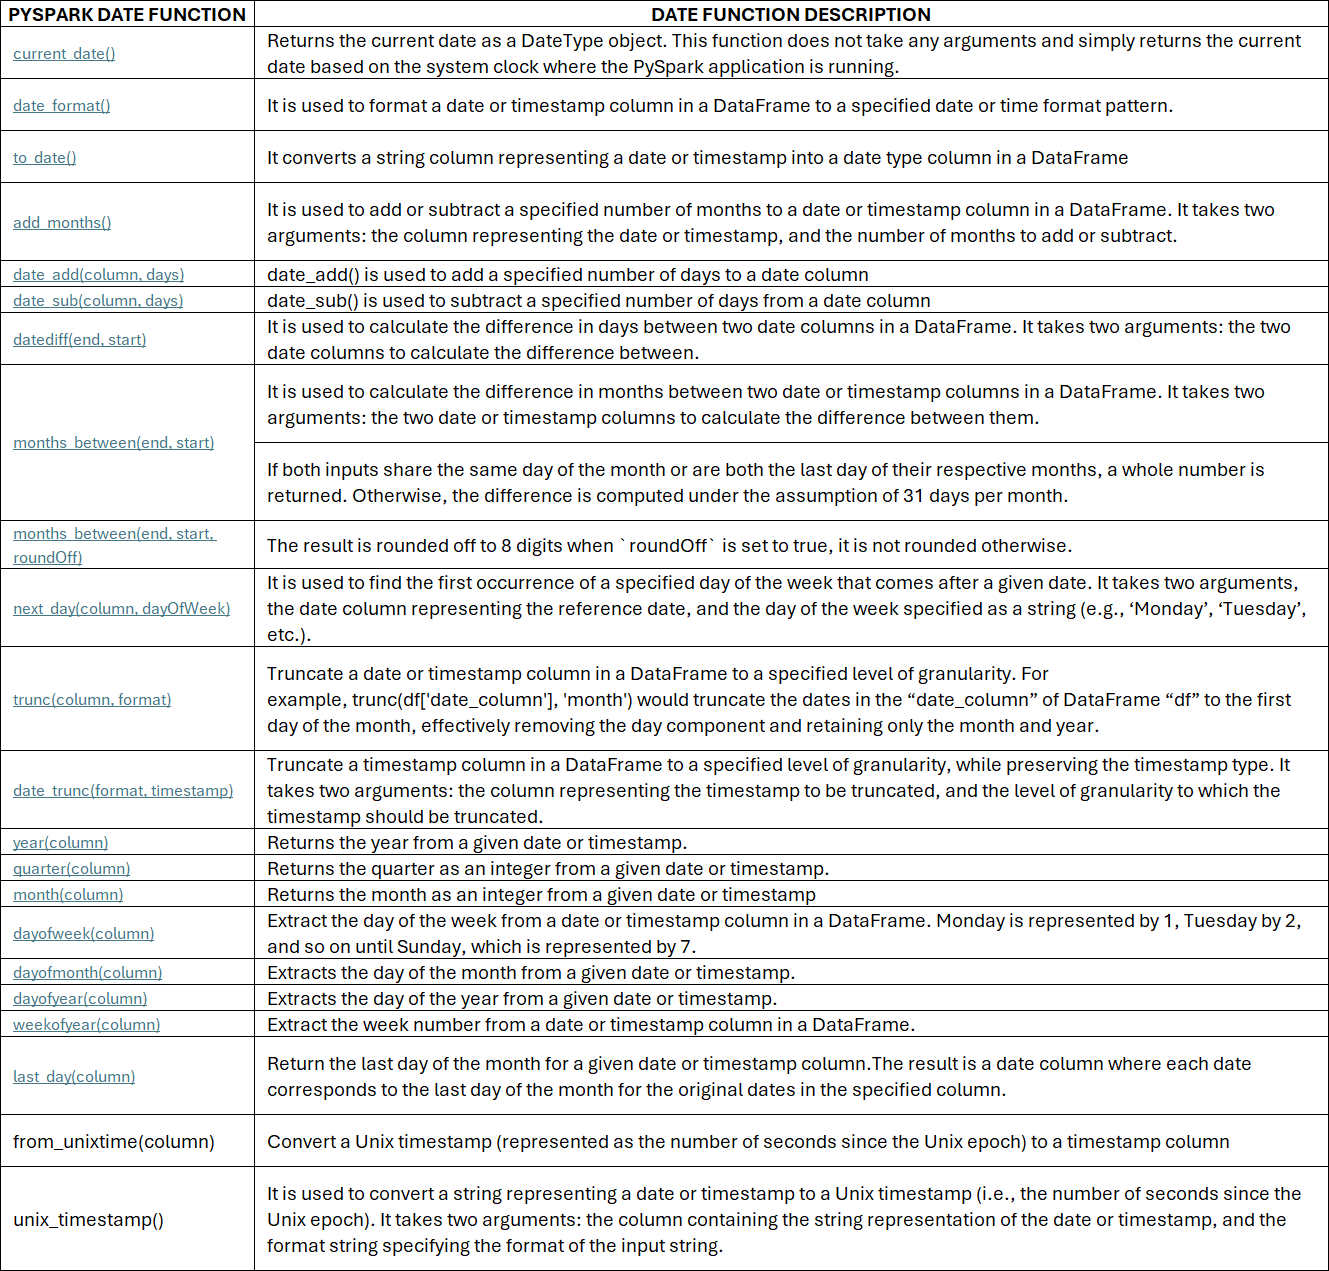

PySpark SQL Timestamp Functions

The default format of the Spark Timestamp is yyyy-MM-dd HH:mm:ss.SSSS


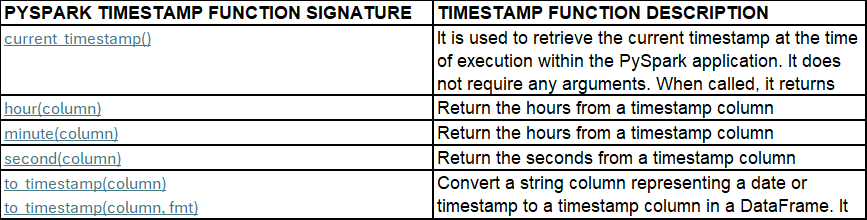

Date and Timestamp Window Functions

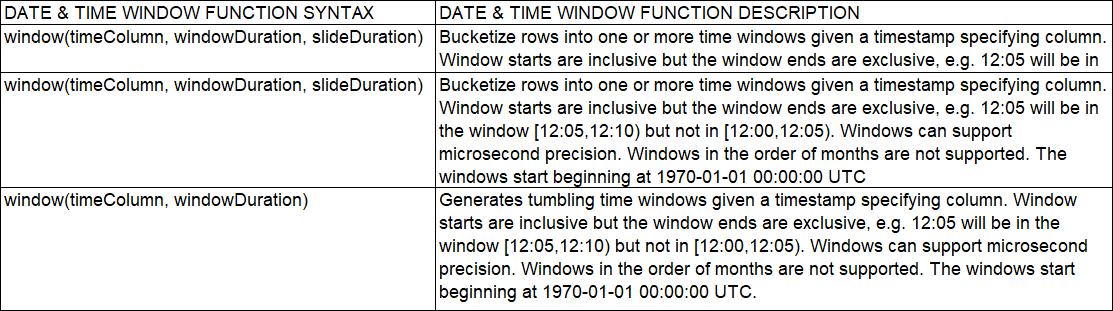

In [52]:
from pyspark.sql import SparkSession
from pyspark.sql.functions import *

# Create SparkSession
spark = SparkSession.builder \
            .appName('SparkByExamples.com') \
            .getOrCreate()
data=[["1","2020-02-01"],["2","2019-03-01"],["3","2021-03-01"]]
df=spark.createDataFrame(data,["id","input"])
df.show()

+---+----------+
| id|     input|
+---+----------+
|  1|2020-02-01|
|  2|2019-03-01|
|  3|2021-03-01|
+---+----------+



In [54]:
df.select(current_date().alias("Current Date")).show(1)

+------------+
|Current Date|
+------------+
|  2026-07-26|
+------------+
only showing top 1 row


In [56]:
#The below example uses date_format() to parses the date and converts from yyyy-dd-mm to MM-dd-yyyy format.
df.select(col("input"), date_format(col('input'), "dd-MM-yyyy").alias("Date Format")).show()

+----------+-----------+
|     input|Date Format|
+----------+-----------+
|2020-02-01| 01-02-2020|
|2019-03-01| 01-03-2019|
|2021-03-01| 01-03-2021|
+----------+-----------+



In [57]:
#Below example converts string in date format yyyy-MM-dd to a DateType yyyy-MM-dd using to_date(). You can also use this to convert into any specific format. PySpark supports all patterns supports on  Java DateTimeFormatter.
df.select(col('input'), to_date(col('input'), 'yyy-MM-dd').alias('To Date')).show()

+----------+----------+
|     input|   To Date|
+----------+----------+
|2020-02-01|2020-02-01|
|2019-03-01|2019-03-01|
|2021-03-01|2021-03-01|
+----------+----------+



In [59]:
#datediff() The below example returns the difference between two dates using datediff().
df.select(col('input'), date_diff(current_date(), col('input')).alias("Diffrence")).show()

+----------+---------+
|     input|Diffrence|
+----------+---------+
|2020-02-01|     2367|
|2019-03-01|     2704|
|2021-03-01|     1973|
+----------+---------+



In [60]:
#The below example returns the months between two dates using months_between().
df.select(col("input"),
    months_between(current_date(),col("input")).alias("months_between")
  ).show()

+----------+--------------+
|     input|months_between|
+----------+--------------+
|2020-02-01|   77.80645161|
|2019-03-01|   88.80645161|
|2021-03-01|   64.80645161|
+----------+--------------+



In [61]:
#The below example truncates the date at a specified unit using trunc().
df.select(col("input"),
    trunc(col("input"),"Month").alias("Month_Trunc"),
    trunc(col("input"),"Year").alias("Month_Year"),
    trunc(col("input"),"Month").alias("Month_Trunc")
   ).show()

+----------+-----------+----------+-----------+
|     input|Month_Trunc|Month_Year|Month_Trunc|
+----------+-----------+----------+-----------+
|2020-02-01| 2020-02-01|2020-01-01| 2020-02-01|
|2019-03-01| 2019-03-01|2019-01-01| 2019-03-01|
|2021-03-01| 2021-03-01|2021-01-01| 2021-03-01|
+----------+-----------+----------+-----------+



In [62]:
#add_months() , date_add(), date_sub()
df.select(col("input"),
    add_months(col("input"),3).alias("add_months"),
    add_months(col("input"),-3).alias("sub_months"),
    date_add(col("input"),4).alias("date_add"),
    date_sub(col("input"),4).alias("date_sub")
  ).show()

+----------+----------+----------+----------+----------+
|     input|add_months|sub_months|  date_add|  date_sub|
+----------+----------+----------+----------+----------+
|2020-02-01|2020-05-01|2019-11-01|2020-02-05|2020-01-28|
|2019-03-01|2019-06-01|2018-12-01|2019-03-05|2019-02-25|
|2021-03-01|2021-06-01|2020-12-01|2021-03-05|2021-02-25|
+----------+----------+----------+----------+----------+



In [63]:
#year(), month(), month(),next_day(), weekofyear()
df.select(col("input"),
     year(col("input")).alias("year"),
     month(col("input")).alias("month"),
     next_day(col("input"),"Sunday").alias("next_day"),
     weekofyear(col("input")).alias("weekofyear")
  ).show()

+----------+----+-----+----------+----------+
|     input|year|month|  next_day|weekofyear|
+----------+----+-----+----------+----------+
|2020-02-01|2020|    2|2020-02-02|         5|
|2019-03-01|2019|    3|2019-03-03|         9|
|2021-03-01|2021|    3|2021-03-07|         9|
+----------+----+-----+----------+----------+



In [64]:
#dayofweek(), dayofmonth(), dayofyear()
df.select(col("input"),
     dayofweek(col("input")).alias("dayofweek"),
     dayofmonth(col("input")).alias("dayofmonth"),
     dayofyear(col("input")).alias("dayofyear"),
  ).show()

+----------+---------+----------+---------+
|     input|dayofweek|dayofmonth|dayofyear|
+----------+---------+----------+---------+
|2020-02-01|        7|         1|       32|
|2019-03-01|        6|         1|       60|
|2021-03-01|        2|         1|       60|
+----------+---------+----------+---------+



In [65]:
data=[["1","02-01-2020 11 01 19 06"],["2","03-01-2019 12 01 19 406"],["3","03-01-2021 12 01 19 406"]]
df2=spark.createDataFrame(data,["id","input"])
df2.show(truncate=False)

+---+-----------------------+
|id |input                  |
+---+-----------------------+
|1  |02-01-2020 11 01 19 06 |
|2  |03-01-2019 12 01 19 406|
|3  |03-01-2021 12 01 19 406|
+---+-----------------------+



In [66]:
df2.select(current_timestamp().alias("current_timestamp")).show(1,truncate=False)

+--------------------------+
|current_timestamp         |
+--------------------------+
|2026-07-26 07:58:46.588677|
+--------------------------+
only showing top 1 row


In [67]:
#to_timestamp() Converts string timestamp to Timestamp type format.
df2.select(col("input"),
    to_timestamp(col("input"), "MM-dd-yyyy HH mm ss SSS").alias("to_timestamp")
  ).show(truncate=False)

+-----------------------+-----------------------+
|input                  |to_timestamp           |
+-----------------------+-----------------------+
|02-01-2020 11 01 19 06 |2020-02-01 11:01:19.06 |
|03-01-2019 12 01 19 406|2019-03-01 12:01:19.406|
|03-01-2021 12 01 19 406|2021-03-01 12:01:19.406|
+-----------------------+-----------------------+



In [68]:
#hour, minute,second
data=[["1","2020-02-01 11:01:19.06"],["2","2019-03-01 12:01:19.406"],["3","2021-03-01 12:01:19.406"]]
df3=spark.createDataFrame(data,["id","input"])

df3.select(col("input"),
    hour(col("input")).alias("hour"),
    minute(col("input")).alias("minute"),
    second(col("input")).alias("second")
  ).show(truncate=False)

+-----------------------+----+------+------+
|input                  |hour|minute|second|
+-----------------------+----+------+------+
|2020-02-01 11:01:19.06 |11  |1     |19    |
|2019-03-01 12:01:19.406|12  |1     |19    |
|2021-03-01 12:01:19.406|12  |1     |19    |
+-----------------------+----+------+------+



#PySpark JSON Functions

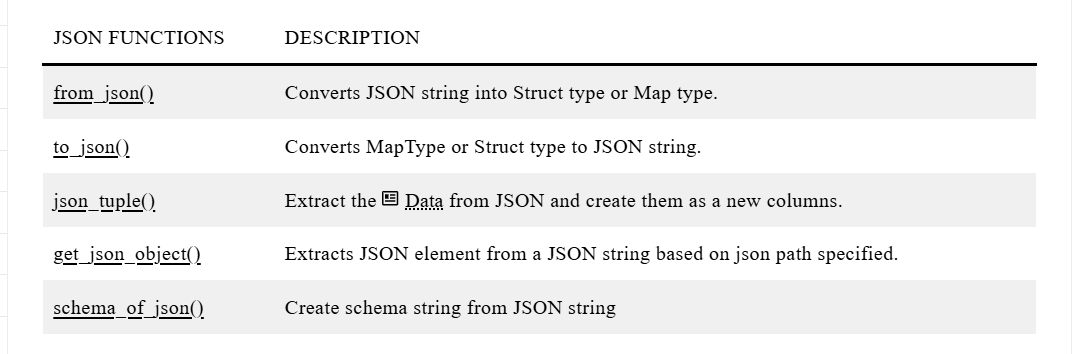

In [69]:
from pyspark.sql import SparkSession,Row
spark = SparkSession.builder.appName('SparkByExamples.com').getOrCreate()

jsonString="""{"Zipcode":704,"ZipCodeType":"STANDARD","City":"PARC PARQUE","State":"PR"}"""
df=spark.createDataFrame([(1, jsonString)],["id","value"])
df.show(truncate=False)

+---+--------------------------------------------------------------------------+
|id |value                                                                     |
+---+--------------------------------------------------------------------------+
|1  |{"Zipcode":704,"ZipCodeType":"STANDARD","City":"PARC PARQUE","State":"PR"}|
+---+--------------------------------------------------------------------------+



PySpark from_json() function is used to convert JSON string into Struct type or Map type. The below example converts JSON string to Map key-value pair. I will leave it to you to convert to struct type. Refer, Convert JSON string to Struct type column.

In [70]:
#Convert JSON string column to Map type
from pyspark.sql.types import MapType,StringType
from pyspark.sql.functions import from_json
df2=df.withColumn("value",from_json(df.value,MapType(StringType(),StringType())))
df2.printSchema()
df2.show(truncate=False)

root
 |-- id: long (nullable = true)
 |-- value: map (nullable = true)
 |    |-- key: string
 |    |-- value: string (valueContainsNull = true)

+---+---------------------------------------------------------------------------+
|id |value                                                                      |
+---+---------------------------------------------------------------------------+
|1  |{Zipcode -> 704, ZipCodeType -> STANDARD, City -> PARC PARQUE, State -> PR}|
+---+---------------------------------------------------------------------------+



2.2. to_json()


to_json() function is used to convert DataFrame columns MapType or Struct type to JSON string. Here, I am using df2 that created from above from_json() example.

In [71]:
from pyspark.sql.functions import to_json,col
df2.withColumn("value",to_json(col("value"))) \
   .show(truncate=False)

+---+----------------------------------------------------------------------------+
|id |value                                                                       |
+---+----------------------------------------------------------------------------+
|1  |{"Zipcode":"704","ZipCodeType":"STANDARD","City":"PARC PARQUE","State":"PR"}|
+---+----------------------------------------------------------------------------+



In [72]:
#Function json_tuple() is used the query or extract the elements from JSON column and create the result as a new columns.
from pyspark.sql.functions import json_tuple
df.select(col("id"),json_tuple(col("value"),"Zipcode","ZipCodeType","City")) \
    .toDF("id","Zipcode","ZipCodeType","City") \
    .show(truncate=False)

+---+-------+-----------+-----------+
|id |Zipcode|ZipCodeType|City       |
+---+-------+-----------+-----------+
|1  |704    |STANDARD   |PARC PARQUE|
+---+-------+-----------+-----------+



In [73]:
#get_json_object() is used to extract the JSON string based on path from the JSON column.
from pyspark.sql.functions import get_json_object
df.select(col("id"),get_json_object(col("value"),"$.ZipCodeType").alias("ZipCodeType")) \
    .show(truncate=False)

+---+-----------+
|id |ZipCodeType|
+---+-----------+
|1  |STANDARD   |
+---+-----------+



In [74]:
#Use schema_of_json() to create schema string from JSON string column.
from pyspark.sql.functions import schema_of_json,lit
schemaStr=spark.range(1) \
    .select(schema_of_json(lit("""{"Zipcode":704,"ZipCodeType":"STANDARD","City":"PARC PARQUE","State":"PR"}"""))) \
    .collect()[0][0]
print(schemaStr)

STRUCT<City: STRING, State: STRING, ZipCodeType: STRING, Zipcode: BIGINT>
